#### для работы в google colab

In [1]:
!gdown 1jxmlIYFahzo2qk8CbjGj1YpEz4YwqYQx

Downloading...
From (original): https://drive.google.com/uc?id=1jxmlIYFahzo2qk8CbjGj1YpEz4YwqYQx
From (redirected): https://drive.google.com/uc?id=1jxmlIYFahzo2qk8CbjGj1YpEz4YwqYQx&confirm=t&uuid=e71660ca-3582-4831-b11a-1e92a23db6c7
To: /kaggle/working/memedataset.zip
100%|██████████████████████████████████████| 23.1M/23.1M [00:00<00:00, 76.8MB/s]


In [ ]:
import zipfile

zip_path = 'memedataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("📁 Архив распакован.")


In [9]:
import pandas as pd

In [10]:
# для google colab

images_folder = '/content/dataset/train/'
test_folder = '/content/dataset/test/'

df = pd.read_csv('/content/dataset/train.csv')
test = pd.read_csv('/content/dataset/test.csv')

df['label'] = (df['label'] == 0).astype(int)
test['label'] = (test['label'] == 0).astype(int)

df.head()

,filename,url,label
0,dd04baf8a1ec4e99b661fc50ce11f3fb.jpg,https://sun1-29.userapi.com/s/v1/ig2/RCHXNPoCm...,0
1,85a5f9b8af0a145df51d2a9ba6722ff9.jpg,https://sun1-19.userapi.com/s/v1/ig2/lMzHt5ja6...,0
2,ba334090dd827a881f02581c09b7980d.jpg,https://sun9-73.userapi.com/s/v1/ig2/nTnnvHD_7...,0
3,bbbc5f3698c7f426b8886a110175a273.jpg,https://sun1-87.userapi.com/s/v1/ig2/WnAX9NlUv...,0
4,ceb955741afa84345f646814b86a5425.jpg,https://sun1-21.userapi.com/s/v1/ig2/tGsdVQTGP...,0


### Выгружаем данные и убираем лишние классы

In [11]:
import pandas as pd
import numpy as np

In [12]:
# для локального запуска
import os

if os.getcwd().split('/')[-1] != 'memobot':
    os.chdir('..')
os.getcwd()


'/'

In [13]:
# images_folder = 'data/train/'
# test_folder = 'data/test/'

# df = pd.read_csv('data/train.csv')
# test = pd.read_csv('data/test.csv')
# df['label'] = (df['label'] == 0).astype(int)
# test['label'] = (test['label'] == 0).astype(int)
# df.head()

## Делаем датасет

In [14]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

class VkDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
from torch.utils.data import random_split
import torch

torch.manual_seed(42)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_data = VkDataset(df, images_folder, transform=transform)
test_data = VkDataset(test, test_folder, transform=transform)

train_ds, val_ds = random_split(train_data, [0.8, 0.2])
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)

test_dl = DataLoader(test_data, batch_size=64, shuffle=False)


groups = ['not cu', 'central_university']


In [ ]:
len(train_data), len(test_data)

# Грузим модельку!

In [22]:
from torchvision import models, transforms
import torch.nn as nn

model = models.efficientnet_b0()

model.classifier[1] = nn.Linear(1280, 2)

In [23]:
from tqdm import tqdm
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()
n_epochs = 10


for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    best_score = 0

    for image, label in tqdm(train_dl, desc=f"Epoch {epoch+1} [Train]", leave=False):
        image, label = image.to(device), label.to(device)
        logits = model(image)
        loss = criterion(logits, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    val_loss = 0
    total_f1 = 0

    for image, label in tqdm(val_dl, desc=f"Epoch {epoch+1} [Val]", leave=False):
        image, label = image.to(device), label.to(device)
        with torch.no_grad():
            logits = model(image)
            loss = criterion(logits, label)
            preds = logits.softmax(dim=1).argmax(dim=1)
        
        total_f1 += f1_score(label.cpu(), preds.cpu())
        val_loss += loss.item()

    total_f1 /= len(val_dl)
    val_loss /= len(val_dl)
    total_loss /= len(train_dl)

    if total_f1 > best_score:
        best_score = total_f1
        torch.save(model.state_dict(), 'efficientnet.pth')

    print(f"Epoch {epoch+1} [Train] Loss: {total_loss:.4f}, [Val] Loss: {val_loss:.4f}, F1: {total_f1:.4f}")

Epoch 1 [Train] Loss: 0.3494, [Val] Loss: 0.4719, F1: 0.0168


Epoch 2 [Train] Loss: 0.2975, [Val] Loss: 0.5979, F1: 0.5834


Epoch 3 [Train] Loss: 0.2317, [Val] Loss: 1.5306, F1: 0.6790


Epoch 4 [Train] Loss: 0.1851, [Val] Loss: 0.2583, F1: 0.7040


Epoch 5 [Train] Loss: 0.1560, [Val] Loss: 0.2429, F1: 0.7167


Epoch 6 [Train] Loss: 0.1404, [Val] Loss: 0.2014, F1: 0.7655


Epoch 7 [Train] Loss: 0.1320, [Val] Loss: 0.1366, F1: 0.8617


Epoch 8 [Train] Loss: 0.1027, [Val] Loss: 0.1286, F1: 0.8470


Epoch 9 [Train] Loss: 0.0787, [Val] Loss: 0.2260, F1: 0.8059


Epoch 10 [Train] Loss: 0.0888, [Val] Loss: 0.2057, F1: 0.7911


In [36]:
model = models.efficientnet_b0()
model.classifier[1] = nn.Linear(1280, 2)

model.load_state_dict(torch.load('/kaggle/working/efficientnet.pth'))

model.eval()
model.to(device)

for image, label in tqdm(test_dl, desc=f"Epoch {epoch+1} [Test]"):
    image, label = image.to(device), label.to(device)
    with torch.no_grad():
        logits = model(image)
        preds = logits.softmax(dim=1).argmax(dim=1)
        
    total_f1 += f1_score(label.cpu(), preds.cpu())
    val_loss += loss.item()

total_f1 /= len(test_dl)
val_loss /= len(test_dl)

print(f"Test F1: {total_f1:.4f} Test Loss: {val_loss:.4f}")

Epoch 10 [Test]: 100%|██████████| 22/22 [00:02<00:00, 10.98it/s]

Test F1: 0.8085 Test Loss: 0.0850


### допом проверим глазками

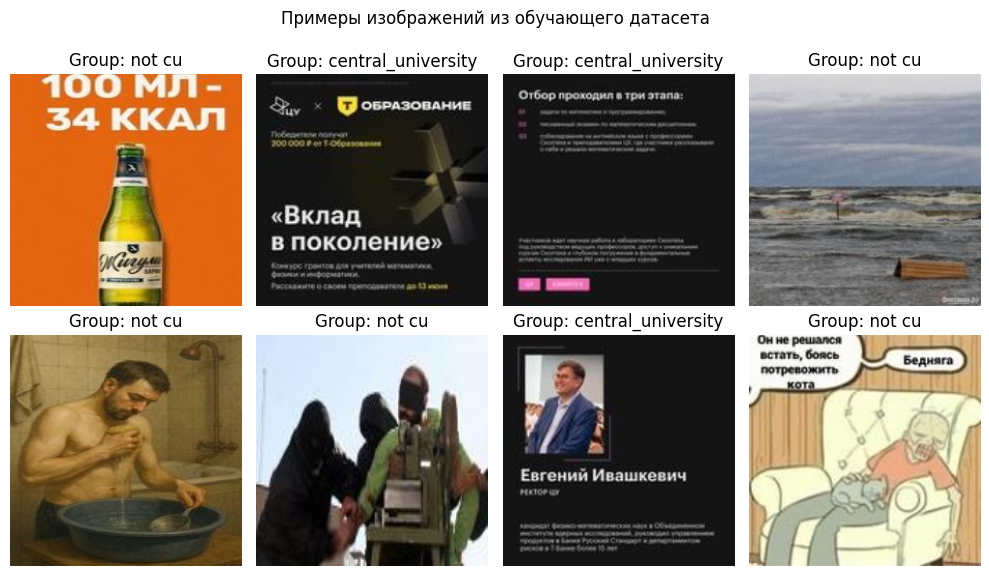

In [37]:
import matplotlib.pyplot as plt

plt.subplots(2, 4, figsize=(10, 6))
plt.suptitle("Примеры изображений из обучающего датасета")
j = 1
for i in np.random.randint(0, len(test_data), 8):
    plt.subplot(2, 4, j)
    j += 1

    img = test_data[i][0].to(device).unsqueeze(0)
    
    with torch.no_grad():
      logit = model(img)
      label = logit.softmax(dim=1).argmax(dim=1).item()
    plt.imshow(test_data[i][0].permute(1, 2, 0).numpy())  # Преобразуем тензор в формат [H, W, C]
    plt.title(f"Group: {groups[label]}")
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [34]:
import shutil

shutil.move('efficientnet.pth', '/kaggle/working/')

'/kaggle/working/efficientnet.pth'

In [33]:
from IPython.display import FileLink
FileLink('/efficientnet.pth')

/efficientnet.pth